# Análise de Recursos Humanos - HR Dataset

## Bibliotecas

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Configuração Visual

In [2]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
paleta = "viridis"

## Carregamento da Basee

In [3]:
df = pd.read_csv("HRDataset_v14.csv")
df.columns = df.columns.str.strip()
df.head()

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,1/17/2019,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2/24/2016,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,5/15/2012,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,1/3/2019,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2/1/2016,0,2


In [4]:
df.shape

(311, 36)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [6]:
df.dtypes.value_counts()

object     18
int64      16
float64     2
Name: count, dtype: int64

## Limpeza dos Dados

### Valores Nulos

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

DateofTermination    207
ManagerID              8
dtype: int64

A coluna `DateofTermination` tem valores nulos por conta de funcionários ainda ativos, então não contabilizam informações erradas.

A coluna `ManagerID` tem valores nulos por conta de funcionários de cargos altos e que não possuem um superior cadastrado na base, também não indicando informações erradas.

In [8]:
df[df["ManagerID"].isnull()][["Employee_Name", "Position", "Department"]]

,Employee_Name,Position,Department
19,"Becker, Scott",Production Technician I,Production
30,"Buccheri, Joseph",Production Technician II,Production
44,"Chang, Donovan E",Production Technician I,Production
88,"Fancett, Nicole",Production Technician II,Production
135,"Hutter, Rosalie",Production Technician II,Production
177,"Manchester, Robyn",Production Technician II,Production
232,"Rivera, Haley",Production Technician I,Production
251,"Sewkumar, Nori",Production Technician I,Production


### Linhas Duplicadas

In [9]:
df.duplicated().sum()

0

In [10]:
df["EmpID"].duplicated().sum()

0

Não existem linhas duplicadas na base.

### Registros Inconsistentes

Analisando a coluna de nomes, foi possível identificar alguns nomes fictícios inseridos na base de dados.

In [11]:
df = df[df["Employee_Name"] != "Voldemort, Lord"].reset_index(drop=True)
df.shape

(310, 36)

In [12]:
df = df[df["Employee_Name"] != "Corleone, Vito"].reset_index(drop=True)
df.shape

(309, 36)

### Conversão das Colunas de Data

As colunas de data estão no formato de texto, sendo convertidas para o formato date

In [13]:
df["DOB"] = pd.to_datetime(df["DOB"], format="%m/%d/%y")
df.loc[df["DOB"].dt.year > 2026, "DOB"] -= pd.DateOffset(years=100)

df["DateofHire"] = pd.to_datetime(df["DateofHire"], format="%m/%d/%Y")
df["DateofTermination"] = pd.to_datetime(df["DateofTermination"], format="%m/%d/%Y")
df["LastPerformanceReview_Date"] = pd.to_datetime(df["LastPerformanceReview_Date"], format="%m/%d/%Y")

In [14]:
df[["DOB", "DateofHire", "DateofTermination", "LastPerformanceReview_Date"]].dtypes

DOB                           datetime64[ns]
DateofHire                    datetime64[ns]
DateofTermination             datetime64[ns]
LastPerformanceReview_Date    datetime64[ns]
dtype: object

### Valore atípicos

In [15]:
df[["Salary", "EngagementSurvey", "EmpSatisfaction", "Absences", "DaysLateLast30"]].describe()

,Salary,EngagementSurvey,EmpSatisfaction,Absences,DaysLateLast30
count,309.000000,309.000000,309.000000,309.000000,309.000000
mean,68546.711974,4.110615,3.889968,10.226537,0.417476
std,24428.198598,0.792054,0.908579,5.864859,1.298283
min,45046.000000,1.120000,1.000000,1.000000,0.000000
25%,55425.000000,3.690000,3.000000,5.000000,0.000000
50%,62659.000000,4.280000,4.000000,10.000000,0.000000
75%,71860.000000,4.700000,5.000000,15.000000,0.000000
max,250000.000000,5.000000,5.000000,20.000000,6.000000


A coluna `Salary` apresenta grande quantidade de valores, sendo alguns muito altos, mas compatíveis com cargos mais altos.

As colunas `EngagementSurvey` e `EmpSatisfaction` apresentam notas compatíveis e sem valores fora do padrão, assim como as colunas `Absences` e `DaysLateLast30`.

## Análise Inicial

### KPI's Gerais

In [16]:
data_referencia = pd.Timestamp("2026-06-27")

df["Idade"] = ((data_referencia - df["DOB"]).dt.days // 365)
df["DataReferenciaTempo"] = df["DateofTermination"].fillna(data_referencia)
df["TempoEmpresaAnos"] = ((df["DataReferenciaTempo"] - df["DateofHire"]).dt.days / 365).round(1)

In [17]:
total_funcionarios = df["EmpID"].count()
funcionarios_ativos = (df["Termd"] == 0).sum()
funcionarios_desligados = (df["Termd"] == 1).sum()
salario_medio = df["Salary"].mean()
tempo_medio_empresa = df["TempoEmpresaAnos"].mean()
idade_media = df["Idade"].mean()
satisfacao_media = df["EmpSatisfaction"].mean()
enagajamento_medio = df["EngagementSurvey"].mean()

kpis = pd.Series({
    "Total de Funcionários": total_funcionarios,
    "Funcionários Ativos": funcionarios_ativos,
    "Funcionários Desativados": funcionarios_desligados,
    "Salário Médio": round(salario_medio,2),
    "Tempo Médio de Empresa": round(tempo_medio_empresa,0),
    "Idade Média": round(idade_media,0),
    "Satisfação Média": round(satisfacao_media,1),
    "Engajamento Médio": round(enagajamento_medio,1)
}).reset_index()
kpis

,index,0
0,Total de Funcionários,309.00
1,Funcionários Ativos,206.00
2,Funcionários Desativados,103.00
3,Salário Médio,68546.71
4,Tempo Médio de Empresa,10.00
5,Idade Média,47.00
6,Satisfação Média,3.90
7,Engajamento Médio,4.10


In [18]:
(df["PerformanceScore"].value_counts(normalize=True).round(3)*100).reset_index()

,PerformanceScore,proportion
0,Fully Meets,78.3
1,Exceeds,11.7
2,Needs Improvement,5.8
3,PIP,4.2


A empresa tem 310 funcionários cadastrados na base, dos quais 207 são ativos ainda e 103 desativados, o que representa uma rotatividade relativamente grande. O sálario médio é de 69 mil dólares anuais.

A idade média dos funcionários é de 47 anos e ficam empregados por um tempo médio de 10 anos, o que representa um bom tempo de empregabilidade.

A satisfação média é de 3.9 de 5.0 e o engajamento médio é de 4.1 de 5.0, o que representa um bom desempenho geral do corpo administrativo da empresa e setores motivados por performance.

## Análises Demográficas

### Distribuição por Sexo

In [19]:
df["Sex"].value_counts().reset_index()

,Sex,count
0,F,176
1,M,133


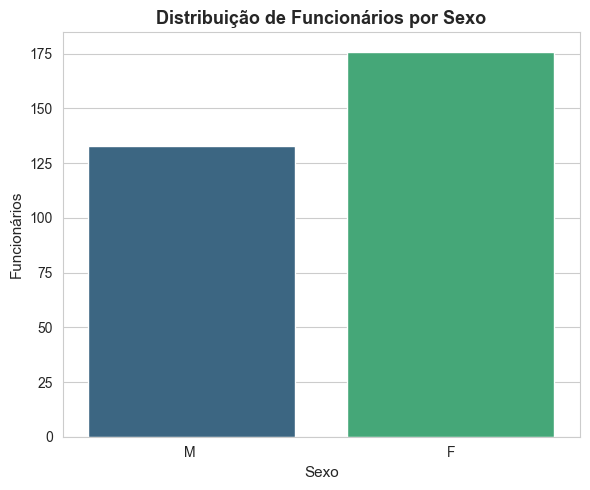

In [20]:
plt.figure(figsize=(6,5))
sns.countplot(data=df, x="Sex", hue="Sex", palette=paleta, legend=False)
plt.xlabel("Sexo")
plt.ylabel("Funcionários")
plt.title("Distribuição de Funcionários por Sexo")
plt.tight_layout()
plt.show()

### Distribuição por Estado Civil

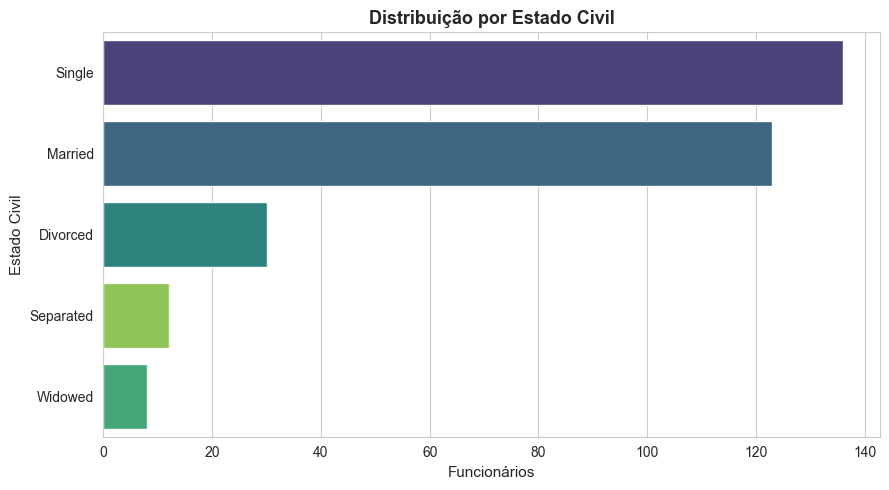

In [21]:
plt.figure(figsize=(9,5))
ordem_estado_civil = df["MaritalDesc"].value_counts().index
sns.countplot(data=df, y="MaritalDesc", order=ordem_estado_civil, hue="MaritalDesc", palette=paleta, legend=False)
plt.xlabel("Funcionários")
plt.ylabel("Estado Civil")
plt.title("Distribuição por Estado Civil")
plt.tight_layout()
plt.show()

### Distribuição por Departamento

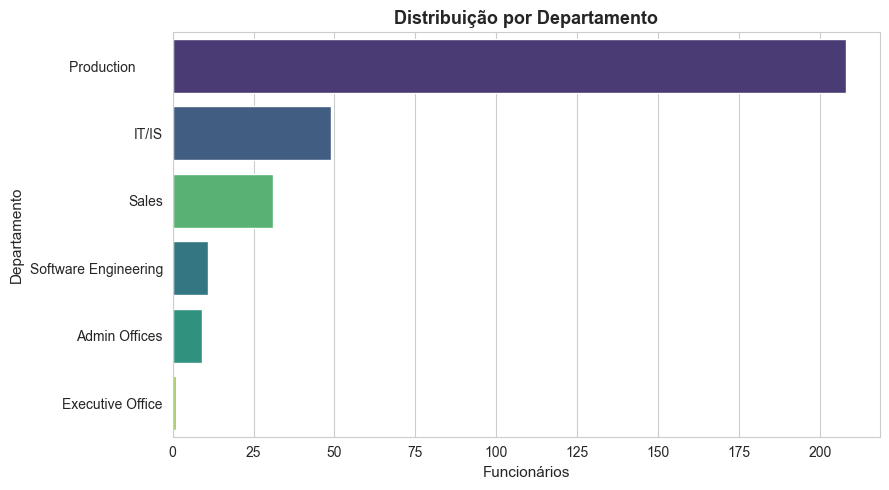

In [22]:
plt.figure(figsize=(9,5))
ordem_departamento = df["Department"].value_counts().index
sns.countplot(data=df, y="Department", order=ordem_departamento, hue="Department", palette=paleta, legend=False)
plt.xlabel("Funcionários")
plt.ylabel("Departamento")
plt.title("Distribuição por Departamento")
plt.tight_layout()
plt.show()

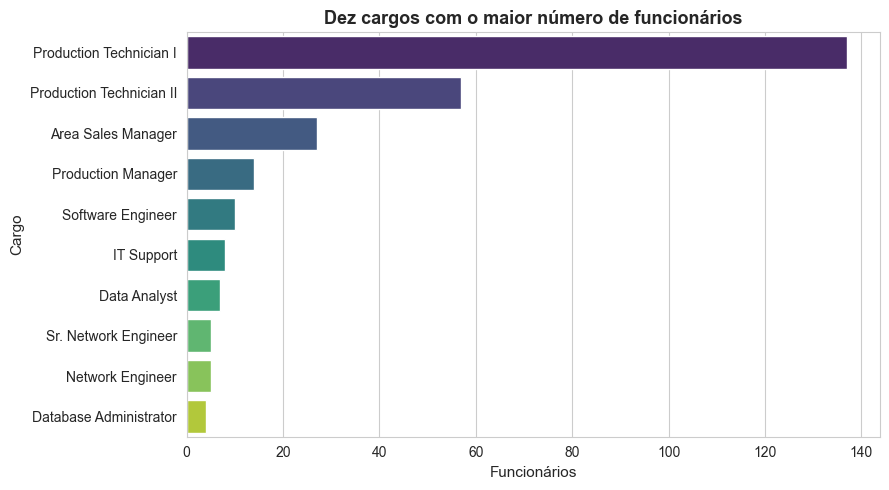

In [23]:
plt.figure(figsize=(9,5))
top_cargos = df["Position"].value_counts().head(10)
sns.barplot(x=top_cargos.values, y=top_cargos.index, hue=top_cargos.index, palette=paleta, legend=False)
plt.xlabel("Funcionários")
plt.ylabel("Cargo")
plt.title("Dez cargos com o maior número de funcionários")
plt.tight_layout()
plt.show()

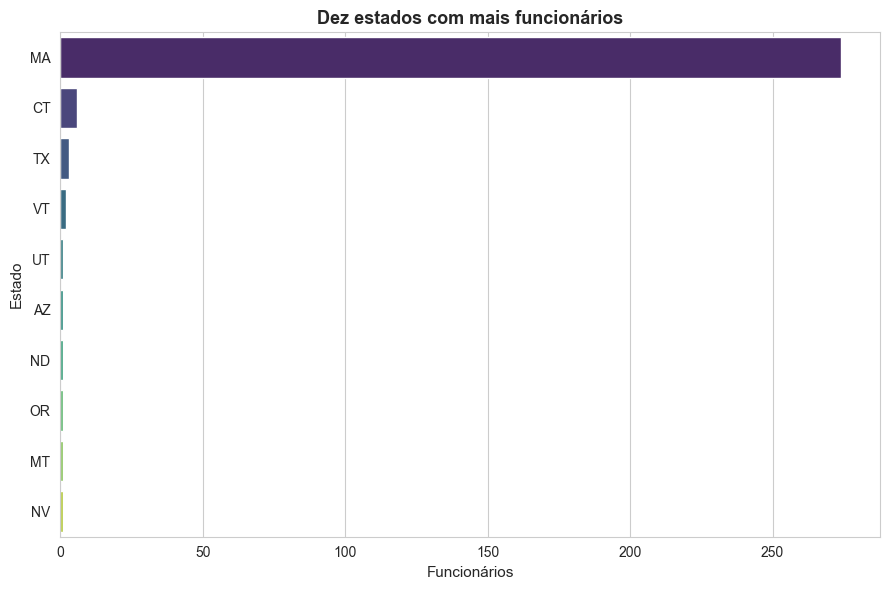

In [24]:
plt.figure(figsize=(9,6))
top_estados = df["State"].value_counts().head(10)
sns.barplot(x=top_estados.values, y=top_estados.index, hue=top_estados.index, palette=paleta, legend=False)
plt.xlabel("Funcionários")
plt.ylabel("Estado")
plt.title("Dez estados com mais funcionários")
plt.tight_layout()
plt.show()

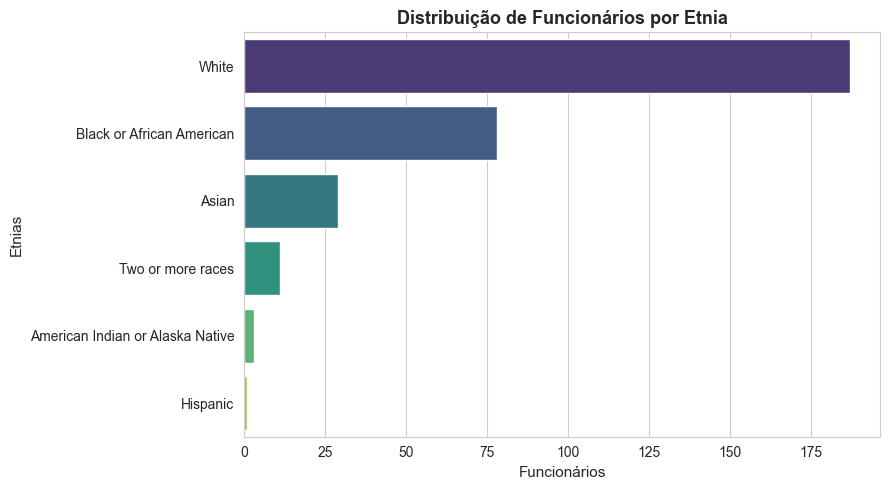

In [25]:
plt.figure(figsize=(9,5))
etnias = df["RaceDesc"].value_counts()
sns.barplot(x=etnias.values, y=etnias.index, hue=etnias.index, palette=paleta, legend=False)
plt.xlabel("Funcionários")
plt.ylabel("Etnias")
plt.title("Distribuição de Funcionários por Etnia")
plt.tight_layout()
plt.show()

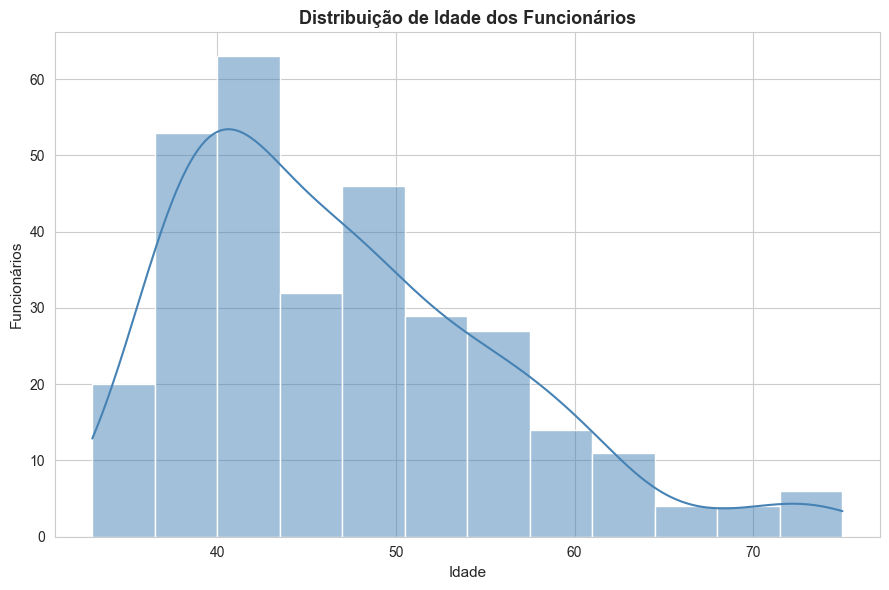

In [26]:
plt.figure(figsize=(9,6))
sns.histplot(data=df, x="Idade", bins="auto", kde=True, color="steelblue")
plt.xlabel("Idade")
plt.ylabel("Funcionários")
plt.title("Distribuição de Idade dos Funcionários")
plt.tight_layout()
plt.show()

A empresa concentra a maior parte dos funcionários em Massachusetts, assim como o departamento de Produção e Cargos Operacionais, o que esta dentro do esperado de acordo com o tipo de atividade da empresa.

A distribuição de sexo é equilibrada, com um número pouco maior de mulheres em relação a homens. O estado civil mais evidente é "solteiro". Em relação a etnia, a predominância é de autodeclarados brancos e, em segundo lugar, negros e africanos.

A idade dos funcionários esta concentrada na faixa de 38~45 anos, indicando um grupo predominante de funcionários em experiência intermediária. O gráfico também mostra poucos funcionários com muita experiência, indicando baixa representatividade de pessoas acima dos 60 anos.

## Análise Salarial

### Salário por Departamento

In [27]:
salario_departamento = df.groupby("Department")["Salary"].mean().round(2).sort_values(ascending=False).reset_index()
salario_departamento

,Department,Salary
0,Executive Office,250000.00
1,IT/IS,96719.04
2,Software Engineering,94989.45
3,Admin Offices,71791.89
4,Sales,69061.26
5,Production,59422.07


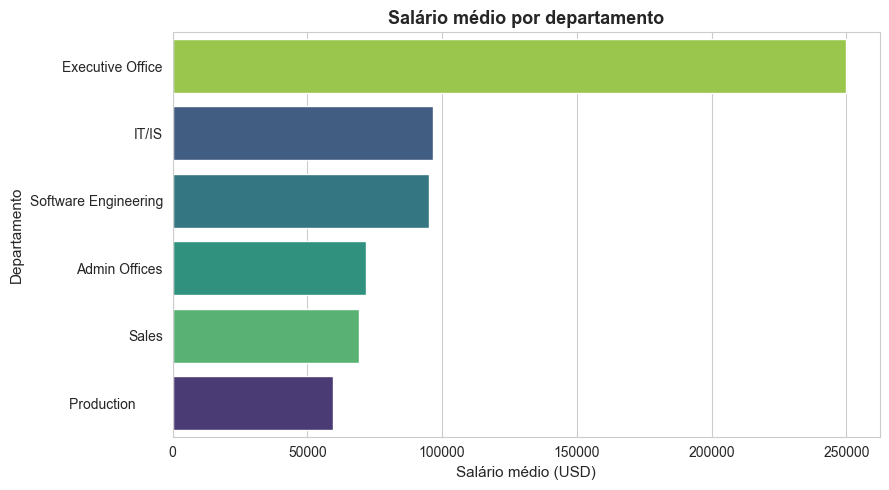

In [28]:
plt.figure(figsize=(9, 5))
ordem_salario_dept = salario_departamento["Department"].values
sns.barplot(data=df, x="Salary", y="Department", order=ordem_salario_dept, hue="Department", palette=paleta, legend=False, errorbar=None)
plt.title("Salário médio por departamento")
plt.xlabel("Salário médio (USD)")
plt.ylabel("Departamento")
plt.tight_layout()
plt.show()

### Salário por Cargo

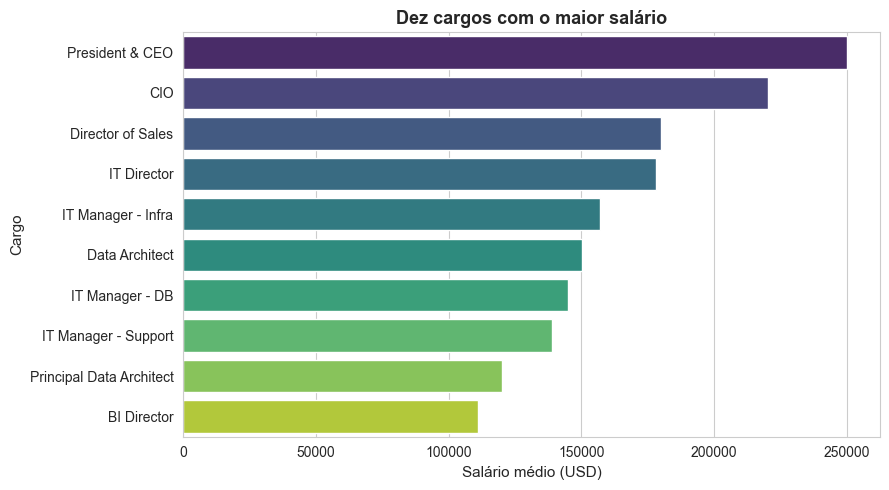

In [29]:
plt.figure(figsize=(9,5))
salario_cargo = df.groupby("Position")["Salary"].mean().sort_values(ascending=False).head(10)
sns.barplot(x=salario_cargo.values, y=salario_cargo.index, hue=salario_cargo.index, palette=paleta, legend=False)
plt.xlabel("Salário médio (USD)")
plt.ylabel("Cargo")
plt.title("Dez cargos com o maior salário")
plt.tight_layout()
plt.show()

### Distribuição Salarial

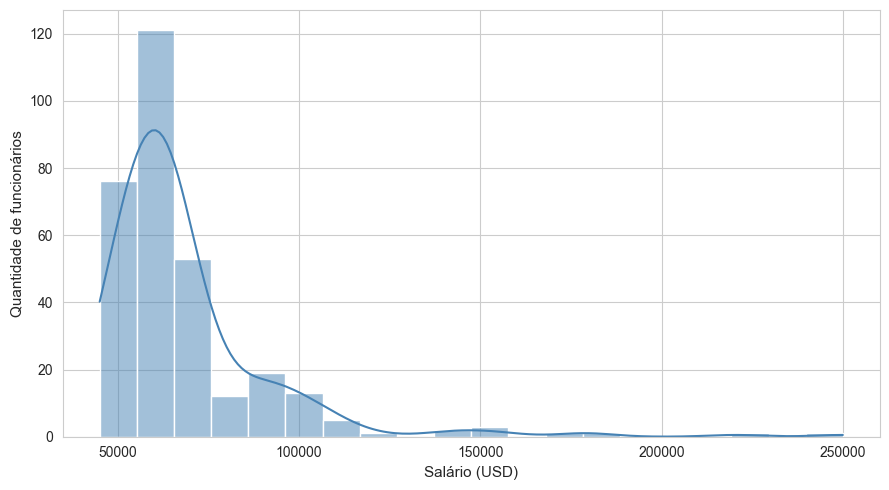

In [30]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="Salary", bins=20, kde=True, color="steelblue")
plt.xlabel("Salário (USD)")
plt.ylabel("Quantidade de funcionários")
plt.tight_layout()
plt.show()

### Funcionários mais bem pagos e menos remunerados

In [31]:
df[["Employee_Name", "Position", "Department", "Salary"]].sort_values("Salary", ascending=False).head(10)

,Employee_Name,Position,Department,Salary
149,"King, Janet",President & CEO,Executive Office,250000
306,"Zamora, Jennifer",CIO,IT/IS,220450
130,"Houlihan, Debra",Director of Sales,Sales,180000
95,"Foss, Jason",IT Director,IT/IS,178000
189,"Monroe, Peter",IT Manager - Infra,IT/IS,157000
239,"Roper, Katie",Data Architect,IT/IS,150290
243,"Ruiz, Ricardo",IT Manager - DB,IT/IS,148999
242,"Roup,Simon",IT Manager - DB,IT/IS,140920
75,"Dougall, Eric",IT Manager - Support,IT/IS,138888
238,"Roehrich, Bianca",Principal Data Architect,IT/IS,120000


In [32]:
df[["Employee_Name", "Position", "Department", "Salary"]].sort_values("Salary", ascending=True).head(10)

,Employee_Name,Position,Department,Salary
308,"Zima, Colleen",Production Technician I,Production,45046
139,"Jacobi, Hannah",Production Technician I,Production,45069
230,"Rhoads, Thomas",Production Technician I,Production,45115
175,"Mahoney, Lauren",Production Technician I,Production,45395
151,"Kirill, Alexandra",Production Technician I,Production,45433
215,"Perry, Shakira",Production Technician I,Production,45998
158,"Langton, Enrico",Production Technician I,Production,46120
73,"Dobrin, Denisa S",Production Technician I,Production,46335
246,"Sadki, Nore",Production Technician I,Production,46428
225,"Purinton, Janine",Production Technician I,Production,46430


### Salário por Gênero

In [33]:
salario_genero = df.groupby("Sex")["Salary"].mean().round(2).reset_index()
salario_genero

,Sex,Salary
0,F,67786.73
1,M,69552.41


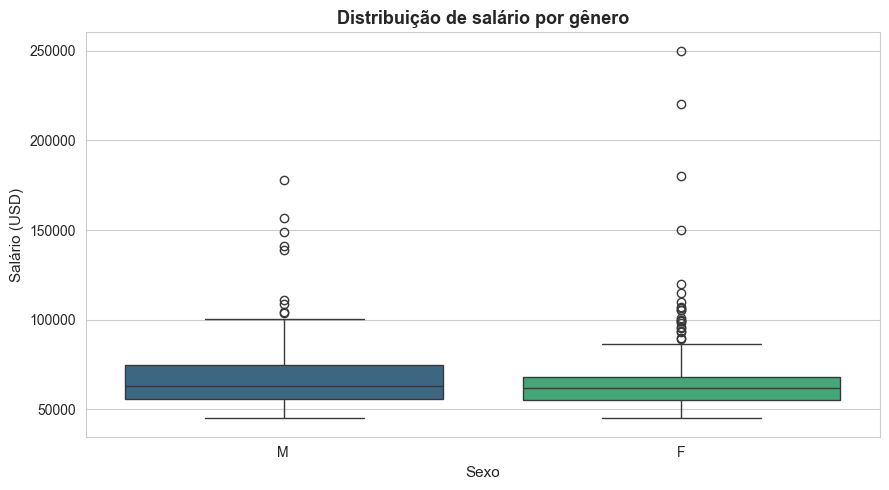

In [34]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="Sex", y="Salary", hue="Sex", palette=paleta, legend=False)
plt.xlabel("Sexo")
plt.ylabel("Salário (USD)")
plt.title("Distribuição de salário por gênero")
plt.tight_layout()
plt.show()

### Salário por Performance

In [35]:
salario_performance = df.groupby("PerformanceScore")["Salary"].mean().round(2).sort_values(ascending=False).reset_index()
salario_performance

,PerformanceScore,Salary
0,Exceeds,74551.67
1,Needs Improvement,68407.56
2,Fully Meets,68178.16
3,PIP,58971.08


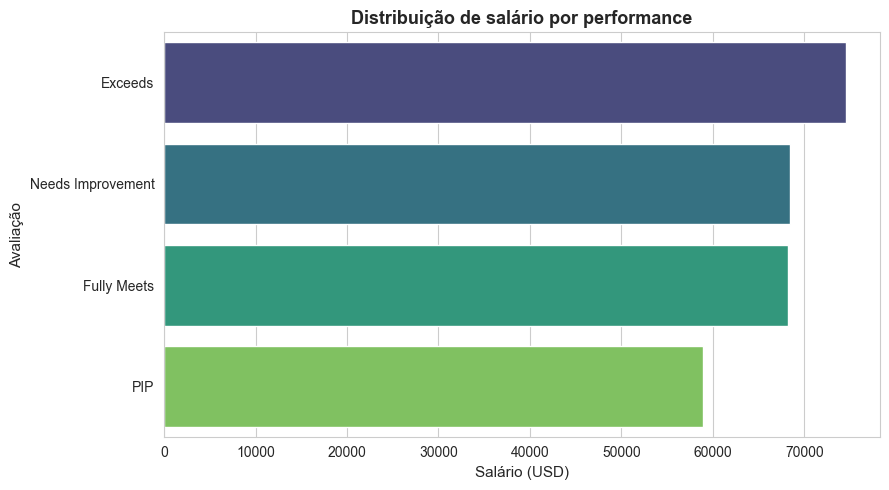

In [96]:
salario_performance_form = df.groupby("PerformanceScore")["Salary"].mean().round(2).sort_values(ascending=False)

plt.figure(figsize=(9,5))
sns.barplot(x=salario_performance_form.values, y=salario_performance_form.index, hue=salario_performance_form.index, palette=paleta, legend=False)
plt.xlabel("Salário (USD)")
plt.ylabel("Avaliação")
plt.title("Distribuição de salário por performance")
plt.tight_layout()
plt.show()

O departamento "Executive Office" recebe a maior média salarial, o que é coerente com os cargos de hierarquia mais alta na empresa. Por outro lado, os cargos relacionados ao departamento de "Production" recebem a menor média salarial, o que também é coerente para cargos de hierarquia operacional.

As diferenças de salários entre os gêneros não são grandes, mas a média salarial dos homens é minimamente maior.

A variação entre os salários relacionados as pontuações de avaliações não é expressiva, o que pode indicar um salário mais associado a posição hierarquica do que uma performance mais elevada.

## Performance

### Distribuição das avaliações

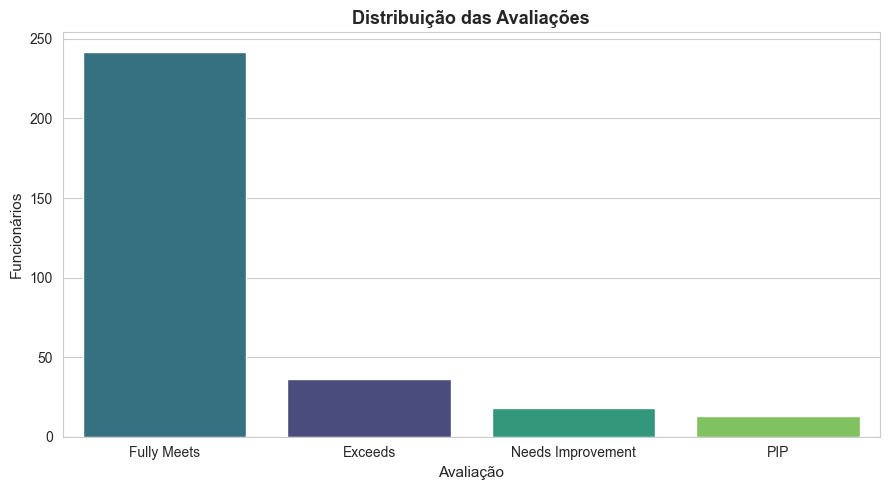

In [37]:
plt.figure(figsize=(9,5))
ordem_avaliacoes = df["PerformanceScore"].value_counts().index
sns.countplot(data=df, x="PerformanceScore", order=ordem_avaliacoes, hue="PerformanceScore", palette=paleta, legend=False)
plt.xlabel("Avaliação")
plt.ylabel("Funcionários")
plt.title("Distribuição das Avaliações")
plt.tight_layout()
plt.show()

### Performance por Departamento

In [38]:
pd.crosstab(df["Department"], df["PerformanceScore"])

PerformanceScore,Exceeds,Fully Meets,Needs Improvement,PIP
Department,,,,
Admin Offices,0,9,0,0
Executive Office,0,1,0,0
IT/IS,6,41,1,1
Production,26,159,15,8
Sales,2,24,1,4
Software Engineering,2,8,1,0


### Performance por gestor

In [39]:
performance_gestor = df.groupby("ManagerName")["PerfScoreID"].mean().round(1).sort_values(ascending=False)
performance_gestor

ManagerName
Eric Dougall          3.2
Alex Sweetwater       3.1
Simon Roup            3.1
Kelley Spirea         3.1
Jennifer Zamora       3.1
Janet King            3.1
David Stanley         3.0
Elijiah Gray          3.0
Brian Champaigne      3.0
Brandon R. LeBlanc    3.0
Ketsia Liebig         3.0
Kissy Sullivan        3.0
Lynn Daneault         3.0
Board of Directors    3.0
Webster Butler        3.0
Amy Dunn              2.9
Michael Albert        2.9
Peter Monroe          2.9
Brannon Miller        2.8
Debra Houlihan        2.7
John Smith            2.7
Name: PerfScoreID, dtype: float64

### Performance por cargo

In [65]:
performance_cargo = df.groupby("Position")["PerfScoreID"].mean().round(1).sort_values(ascending=False).head(10)
performance_cargo

Position
IT Manager - Support            4.0
CIO                             4.0
IT Director                     4.0
Data Analyst                    3.3
IT Support                      3.1
Software Engineer               3.1
Sr. DBA                         3.0
Sr. Accountant                  3.0
Software Engineering Manager    3.0
Shared Services Manager         3.0
Name: PerfScoreID, dtype: float64

### Funcionários com pior e melhor avaliação

In [41]:
df[df["PerformanceScore"] == "Exceeds"][["Employee_Name", "Position", "Department", "PerformanceScore"]]

,Employee_Name,Position,Department,PerformanceScore
0,"Adinolfi, Wilson K",Production Technician I,Production,Exceeds
5,"Anderson, Linda",Production Technician I,Production,Exceeds
12,"Barbossa, Hector",Data Analyst,IT/IS,Exceeds
16,"Beak, Kimberly",Production Technician II,Production,Exceeds
22,"Billis, Helen",Production Technician I,Production,Exceeds
36,"Candie, Calvin",Production Manager,Production,Exceeds
51,"Clukey, Elijian",Production Technician I,Production,Exceeds
75,"Dougall, Eric",IT Manager - Support,IT/IS,Exceeds
76,"Driver, Elle",Area Sales Manager,Sales,Exceeds
95,"Foss, Jason",IT Director,IT/IS,Exceeds


In [42]:
df[df["PerformanceScore"] == "PIP"][["Employee_Name", "Position", "Department", "PerformanceScore"]]

,Employee_Name,Position,Department,PerformanceScore
66,"Delarge, Alex",Area Sales Manager,Sales,PIP
68,"Desimone, Carl",Production Technician I,Production,PIP
71,"Dietrich, Jenna",Area Sales Manager,Sales,PIP
82,"Erilus, Angela",Production Technician II,Production,PIP
89,"Fernandes, Nilson",Production Technician I,Production,PIP
90,"Fett, Boba",Network Engineer,IT/IS,PIP
94,"Forrest, Alex",Area Sales Manager,Sales,PIP
111,"Gonzalez, Juan",Production Technician II,Production,PIP
187,"Miller, Ned",Production Technician II,Production,PIP
204,"O'hare, Lynn",Production Technician I,Production,PIP


### Satisfação

In [43]:
satisfacao_dpt = df.groupby("Department")["EmpSatisfaction"].mean().round(1).sort_values(ascending=False)
satisfacao_dpt

Department
Software Engineering    4.1
IT/IS                   4.0
Sales                   4.0
Production              3.9
Admin Offices           3.6
Executive Office        3.0
Name: EmpSatisfaction, dtype: float64

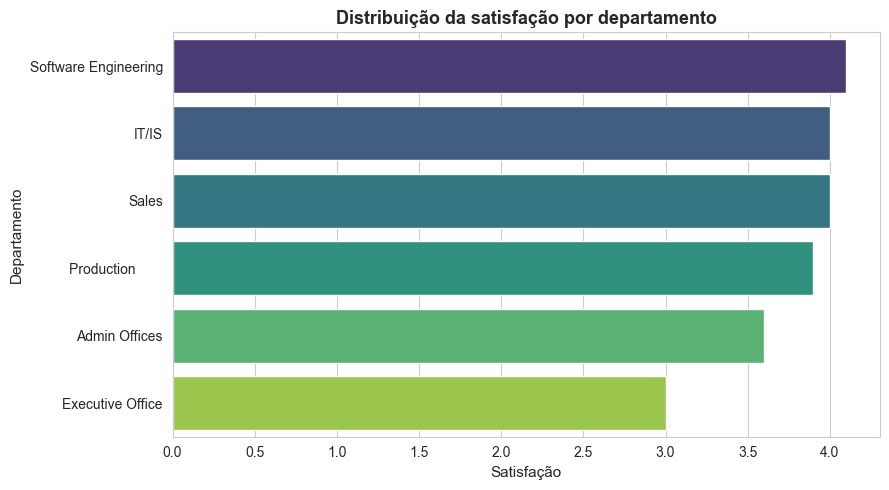

In [44]:
plt.figure(figsize=(9,5))
sns.barplot(x=satisfacao_dpt.values, y=satisfacao_dpt.index, hue=satisfacao_dpt.index, palette=paleta, legend=False)
plt.xlabel("Satisfação")
plt.ylabel("Departamento")
plt.title("Distribuição da satisfação por departamento")
plt.tight_layout()
plt.show()

### Satisfação por Cargo

In [45]:
satisfacao_cargo = df.groupby("Position")["EmpSatisfaction"].mean().round(1).sort_values(ascending=False)
satisfacao_cargo

Position
IT Manager - Support            5.0
Enterprise Architect            5.0
BI Director                     5.0
CIO                             5.0
IT Director                     5.0
IT Manager - DB                 4.5
Sales Manager                   4.3
Software Engineer               4.2
Sr. Network Engineer            4.2
BI Developer                    4.2
Database Administrator          4.0
Director of Sales               4.0
Sr. DBA                         4.0
Area Sales Manager              4.0
Shared Services Manager         4.0
Senior BI Developer             4.0
IT Support                      4.0
Data Analyst                    3.9
Production Technician I         3.9
Production Technician II        3.8
Accountant I                    3.7
Sr. Accountant                  3.5
Production Manager              3.4
Administrative Assistant        3.3
Network Engineer                3.2
Principal Data Architect        3.0
President & CEO                 3.0
IT Manager - Infra 

### Satisfação por gestor

In [46]:
satisfacao_gestor = df.groupby("ManagerName")["EmpSatisfaction"].mean().round(1).sort_values(ascending=False)
satisfacao_gestor

ManagerName
Debra Houlihan        4.3
Jennifer Zamora       4.3
Alex Sweetwater       4.2
Lynn Daneault         4.1
Ketsia Liebig         4.1
Michael Albert        4.0
Elijiah Gray          4.0
Webster Butler        4.0
David Stanley         4.0
Brian Champaigne      4.0
John Smith            3.9
Kissy Sullivan        3.9
Peter Monroe          3.9
Simon Roup            3.9
Amy Dunn              3.8
Kelley Spirea         3.8
Brandon R. LeBlanc    3.6
Janet King            3.6
Eric Dougall          3.5
Brannon Miller        3.4
Board of Directors    3.0
Name: EmpSatisfaction, dtype: float64

### Relação entre satisfação e desempenho

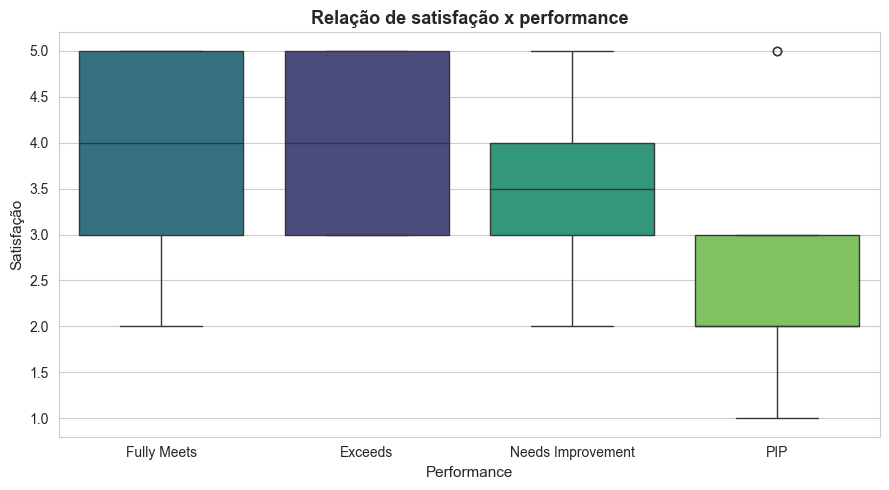

In [47]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="PerformanceScore", y="EmpSatisfaction", order=ordem_avaliacoes, hue="PerformanceScore", palette=paleta, legend=False)
plt.xlabel("Performance")
plt.ylabel("Satisfação")
plt.title("Relação de satisfação x performance")
plt.tight_layout()
plt.show()

Os níveis de satisfação entre os departamento estão bem próximos, sem grandes desigualdades, o que pode indicar uma percepção mais homogênea sobre o ambiente de trabalho ao longo da empresa. Contudo, o departamento de "Executive Office" apresenta a média de satisfação mais baixa (3.0) entre os setores, indicando que o corpo administrativo da empresa possa enfrentar problemas.

As médias de performance dos gestores são relativamente baixas, variando entre 2.7 e 3.2, o que pode indicar um desempenho abaixo da média ou ruim muito vezes.

## Engajamento

### Engajamento por departamento

In [48]:
engajamento_dpt = df.groupby("Department")["EngagementSurvey"].mean().round(1).sort_values(ascending=False)
engajamento_dpt

Department
Executive Office        4.8
Admin Offices           4.4
IT/IS                   4.2
Production              4.1
Software Engineering    4.1
Sales                   3.8
Name: EngagementSurvey, dtype: float64

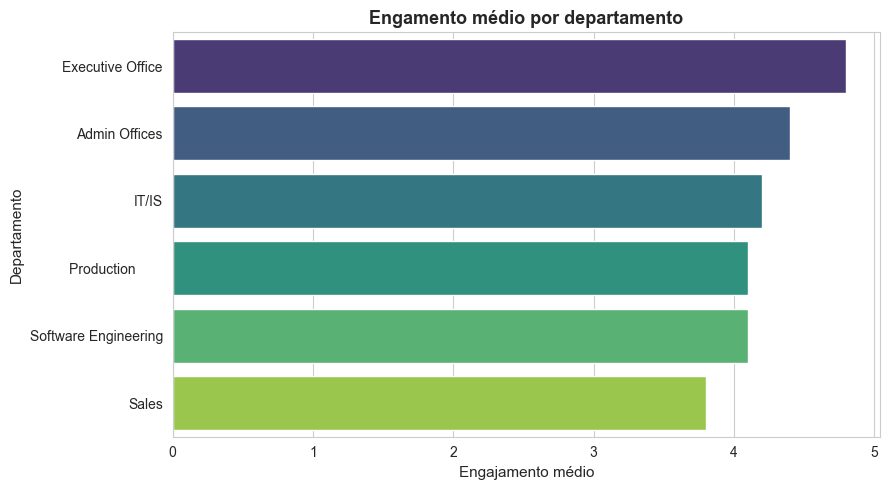

In [49]:
plt.figure(figsize=(9,5))
sns.barplot(x=engajamento_dpt.values, y=engajamento_dpt.index, hue=engajamento_dpt.index, palette=paleta, legend=False)
plt.xlabel("Engajamento médio")
plt.ylabel("Departamento")
plt.title("Engamento médio por departamento")
plt.tight_layout()
plt.show()

In [50]:
engajamento_gestor = df.groupby("ManagerName")["EngagementSurvey"].mean().round(1).sort_values(ascending=False)
engajamento_gestor

ManagerName
Board of Directors    4.9
Eric Dougall          4.6
Kelley Spirea         4.5
Webster Butler        4.3
Brandon R. LeBlanc    4.3
Simon Roup            4.2
Janet King            4.2
David Stanley         4.2
Elijiah Gray          4.1
Brian Champaigne      4.1
Michael Albert        4.1
Alex Sweetwater       4.1
Jennifer Zamora       4.0
Ketsia Liebig         4.0
Kissy Sullivan        4.0
Peter Monroe          4.0
Brannon Miller        4.0
Amy Dunn              3.9
Debra Houlihan        3.8
John Smith            3.8
Lynn Daneault         3.8
Name: EngagementSurvey, dtype: float64

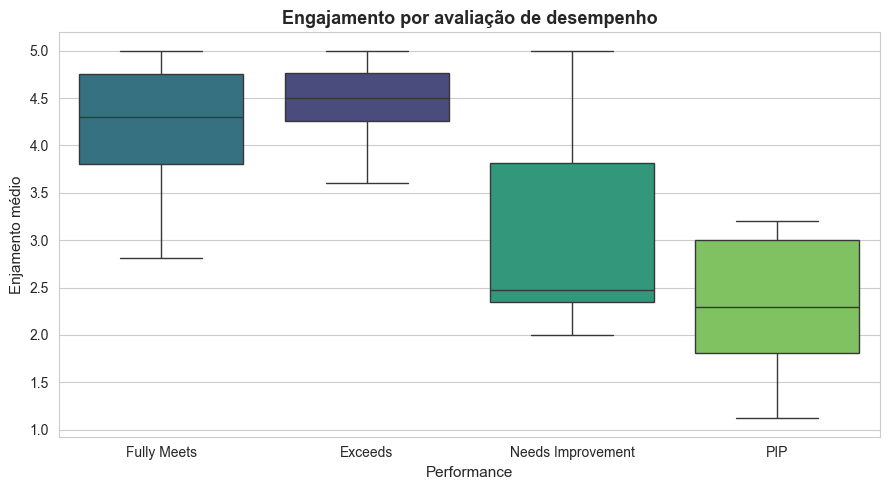

In [51]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="PerformanceScore", y="EngagementSurvey", hue="PerformanceScore", order=ordem_avaliacoes, palette=paleta, legend=False)
plt.xlabel("Performance")
plt.ylabel("Enjamento médio")
plt.title("Engajamento por avaliação de desempenho")
plt.tight_layout()
plt.show()

Os níveis de engajamento médio seguem padrões similares aos de satisfação, com médias muito próximas e sem grandes desigualdades, indicando um enjamento mais homogêneo entre os departamentos.

Em relação aos níveis de engajamento médio por gestor, eles são elevados e semelhantes aos níveis de satisfação, indicando que os líderes estão motivados e satisfeitos com resultados.

Funcionários com performance em "PIP" tendem a apresentar engajamento médio mais baixo, o que é coerente, já que a falta de engajamento pode impactar diretamente na performance dos resultados.

## Absenteísmo

### Dias de atraso e faltas - Visão geral

In [52]:
df[["DaysLateLast30", "Absences"]].describe()

,DaysLateLast30,Absences
count,309.000000,309.000000
mean,0.417476,10.226537
std,1.298283,5.864859
min,0.000000,1.000000
25%,0.000000,5.000000
50%,0.000000,10.000000
75%,0.000000,15.000000
max,6.000000,20.000000


### Departamentos com maior atraso médio

In [53]:
dpt_maior_atraso = df.groupby("Department")["DaysLateLast30"].mean().round(2).sort_values(ascending=False)
dpt_maior_atraso

Department
Sales                   0.65
Production              0.47
Software Engineering    0.36
IT/IS                   0.14
Admin Offices           0.00
Executive Office        0.00
Name: DaysLateLast30, dtype: float64

### Departamentos com maior número médio de faltas e atraso

In [54]:
dpt_mais_faltas = df.groupby("Department")["Absences"].mean().round(2).sort_values(ascending=False)
dpt_mais_faltas

Department
Sales                   11.55
IT/IS                   10.47
Production              10.12
Executive Office        10.00
Software Engineering     8.73
Admin Offices            8.67
Name: Absences, dtype: float64

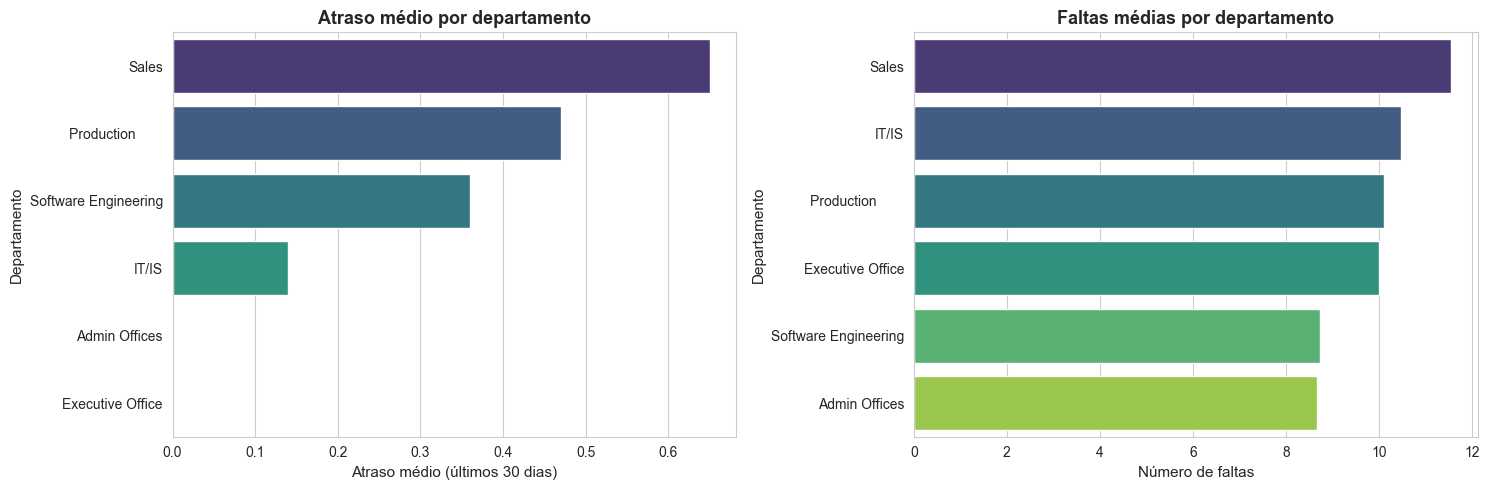

In [87]:
fig, eixos = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(x=dpt_maior_atraso.values, y=dpt_maior_atraso.index, hue=dpt_maior_atraso.index, palette=paleta, legend=False, ax=eixos[0])
eixos[0].set_title("Atraso médio por departamento")
eixos[0].set_xlabel("Atraso médio (últimos 30 dias)")
eixos[0].set_ylabel("Departamento")

sns.barplot(x=dpt_mais_faltas.values, y=dpt_mais_faltas.index, hue=dpt_mais_faltas.index, palette=paleta, legend=False, ax=eixos[1])
eixos[1].set_title("Faltas médias por departamento")
eixos[1].set_xlabel("Número de faltas")
eixos[1].set_ylabel("Departamento")

plt.tight_layout()
plt.show()

### Funcionários com mais atrasos e faltas

In [57]:
df[["Employee_Name", "Position", "Department", "DaysLateLast30"]].sort_values("DaysLateLast30", ascending=False).head(10)

,Employee_Name,Position,Department,DaysLateLast30
66,"Delarge, Alex",Area Sales Manager,Sales,6
89,"Fernandes, Nilson",Production Technician I,Production,6
187,"Miller, Ned",Production Technician II,Production,6
204,"O'hare, Lynn",Production Technician I,Production,6
262,"Sparks, Taylor",Production Technician I,Production,6
295,"Wallace, Theresa",Production Technician I,Production,6
214,"Pelletier, Ermine",Production Technician II,Production,5
305,"Ybarra, Catherine",Production Technician I,Production,5
84,"Evensen, April",Production Technician I,Production,5
83,"Estremera, Miguel",Production Technician I,Production,5


In [58]:
df[["Employee_Name", "Position", "Department", "Absences"]].sort_values("Absences", ascending=False).head(10)

,Employee_Name,Position,Department,Absences
154,"Kreuger, Freddy",Area Sales Manager,Sales,20
15,"Bates, Norman",Production Technician I,Production,20
108,"Goeth, Amon",IT Support,IT/IS,20
113,"Good, Susan",Production Technician II,Production,20
120,"Guilianno, Mike",Area Sales Manager,Sales,20
122,"Hankard, Earnest",Production Technician II,Production,20
92,"Fitzpatrick, Michael J",Production Technician II,Production,20
157,"Langford, Lindsey",Production Technician II,Production,20
160,"Latif, Mohammed",Production Technician II,Production,20
163,"LeBlanc, Brandon R",Shared Services Manager,Admin Offices,20


As faltas não estão concentradas em um único departamento, o que pode indicar que se trata mais de uma questão pessoal, do que um problema estrutural de um departamento específico.

O departamento de "Sales" apresenta o maior atraso médio nos últimos 30 dias, enquanto "Admin Offices" e "Executive Offices" não apresentam registros no mesmo período.

## Turnover

A taxa de turnover será calculada através da divisão do número de funcionários desligados pelo total de funcionários cadastrados na base, seguindo da multiplicação do resultado por 100.

In [59]:
turnover_geral = round((df[df["Termd"] == 1].shape[0] / total_funcionarios) * 100,2)
turnover_geral

33.33

### Turnover por departamento

In [60]:
turnover_dpt = round((df.groupby("Department")["Termd"].mean() * 100).sort_values(ascending=False),2)
turnover_dpt

Department
Production              39.90
Software Engineering    36.36
Admin Offices           22.22
IT/IS                   18.37
Sales                   16.13
Executive Office         0.00
Name: Termd, dtype: float64

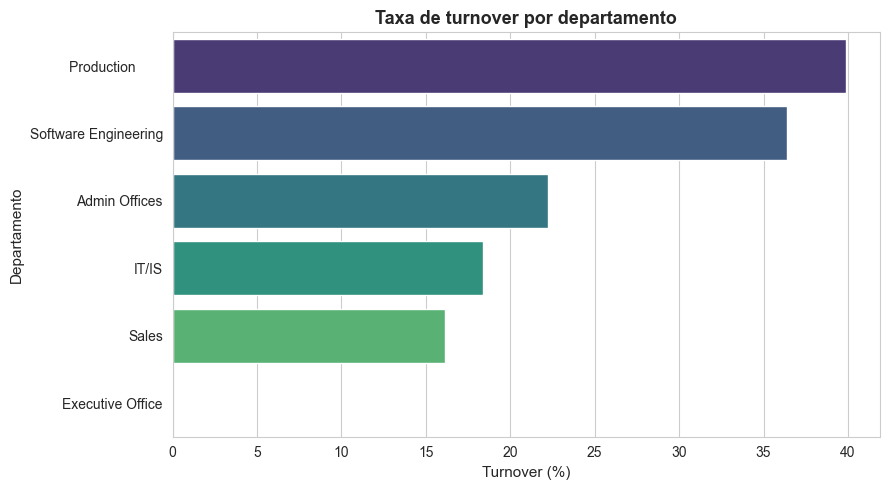

In [61]:
plt.figure(figsize=(9,5))
sns.barplot(x=turnover_dpt.values, y=turnover_dpt.index, hue=turnover_dpt.index, palette=paleta, legend=False)
plt.xlabel("Turnover (%)")
plt.ylabel("Departamento")
plt.title("Taxa de turnover por departamento")
plt.tight_layout()
plt.show()

### Turnover por cargo

In [63]:
turnover_cargo = round((df.groupby("Position")["Termd"].mean() * 100).sort_values(ascending=False),2).head(10)
turnover_cargo

Position
Principal Data Architect    100.00
Data Analyst                100.00
Enterprise Architect        100.00
Administrative Assistant     66.67
Sr. DBA                      50.00
Database Administrator       50.00
IT Manager - DB              50.00
Production Technician II     45.61
Software Engineer            40.00
Production Technician I      37.96
Name: Termd, dtype: float64

In [66]:
turnover_gestor = round((df.groupby("ManagerName")["Termd"].mean() * 100).sort_values(ascending=False),2).head(10)
turnover_gestor

ManagerName
Webster Butler     61.90
Amy Dunn           61.90
Kissy Sullivan     54.55
Simon Roup         43.75
Michael Albert     40.91
Elijiah Gray       36.36
Debra Houlihan     33.33
Alex Sweetwater    33.33
Janet King         33.33
David Stanley      28.57
Name: Termd, dtype: float64

O turnover geral da empresa é de 33%, o que é uma taxa equilibrada considerando todo os histórico de contratações e demissões em um intervalo de anos. 

O departamento com maior rotatividade é o "Production", o que é coerente com uma posição com maior número de funcionários e de hierarquia operacional.

Por outro lado, o departameto de "Executive Offices" não apresenta registros de desligamentos no período analisado.

Em relação ao turnover por cargo, "Principal Data Architect", "Data Analyst", "Enterprise Architec" e "Administrative Assistant" apresentam valores muito altos e acima de 60%, sendo as 3 primeiras com 100% de rotatividade. 

Além disso, comparando os mesmos cargos com os níveis médios de satisfação, performance e engajamento, percebe-se valores muito baixos, o que pode indicar um problema estrutural da empresa nessas posição, gerando alta rotatividade.

## Tempo de empresa

In [67]:
df["TempoEmpresaAnos"].mean().round(1)

9.7

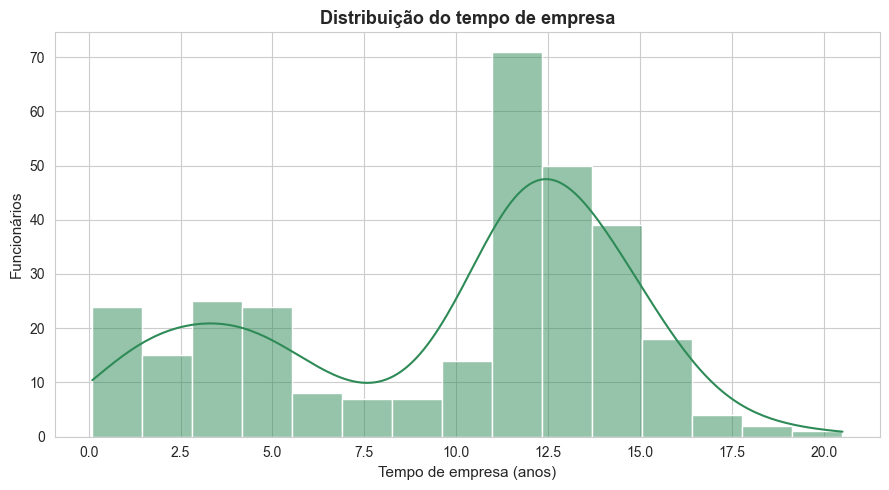

In [69]:
plt.figure(figsize=(9,5))
sns.histplot(data=df, x="TempoEmpresaAnos", bins=15, kde=True, color="seagreen")
plt.xlabel("Tempo de empresa (anos)")
plt.ylabel("Funcionários")
plt.title("Distribuição do tempo de empresa")
plt.tight_layout()
plt.show()

### Funcionários com maior tempo de empresa

In [80]:
df[["Employee_Name", "Position", "Department", "DateofHire", "TempoEmpresaAnos"]].sort_values("TempoEmpresaAnos", ascending=False).head(10)

,Employee_Name,Position,Department,DateofHire,TempoEmpresaAnos
281,"Torrence, Jack",Area Sales Manager,Sales,2006-01-09,20.5
221,"Pitt, Brad",Production Technician I,Production,2007-11-05,18.7
3,"Alagbe,Trina",Production Technician I,Production,2008-01-07,18.5
29,"Brown, Mia",Accountant I,Admin Offices,2008-10-27,17.7
96,"Foster-Baker, Amy",Sr. Accountant,Admin Offices,2009-01-05,17.5
270,"Sullivan, Kissy",Production Manager,Production,2009-01-08,17.5
8,"Bachiochi, Linda",Production Technician I,Production,2009-07-06,17.0
98,"Galia, Lisa",IT Support,IT/IS,2010-05-01,16.2
78,"Dunne, Amy",Production Technician I,Production,2010-04-26,16.2
306,"Zamora, Jennifer",CIO,IT/IS,2010-04-10,16.2


### Funcionários recém contratados

In [78]:
df[["Employee_Name", "Position", "Department", "DateofHire", "TempoEmpresaAnos"]].sort_values("TempoEmpresaAnos", ascending=True).head(10)

,Employee_Name,Position,Department,DateofHire,TempoEmpresaAnos
232,"Roberson, May",Production Technician II,Production,2011-09-26,0.1
107,"Goble, Taisha",Database Administrator,IT/IS,2015-02-16,0.1
131,"Howard, Estelle",Administrative Assistant,Admin Offices,2015-02-16,0.2
294,"Wallace, Courtney E",Production Manager,Production,2011-09-26,0.3
233,"Robertson, Peter",Production Technician II,Production,2011-07-05,0.6
128,"Homberger, Adrienne J",Production Technician II,Production,2011-08-15,0.6
225,"Purinton, Janine",Production Technician I,Production,2012-09-24,0.7
248,"Salter, Jason",Data Analyst,IT/IS,2015-01-05,0.8
27,"Bozzi, Charles",Production Manager,Production,2013-09-30,0.9
160,"Latif, Mohammed",Production Technician II,Production,2012-04-02,1.0


O tempo médio de empresa é de aproximadamente 9 anos e meio, o que indica um quadro de funcionários mais experiente. A maior concetração fica entre 11 e 13 anos de empresa, com poucos funcionários acima dos 15 anos de empresa.

Os funcionários mais antigos foram contratados nos primeiros anos listados na base, enquanto os mais novos foram contratados próximos a última data de contração listada na base.

## Projetos Especiais

A coluna `SpecialProjectsCount` contabiliza quantos projetos especiais determinado funcionário participou. Para essa análise, os funcionários serão divididos em dois grupos: participou de pelo menos um (True) e não participou (False).

In [88]:
projetos_especiais = df.groupby(df["SpecialProjectsCount"]>0)[["Salary", "EngagementSurvey", "EmpSatisfaction"]].mean().round(2)
projetos_especiais

,Salary,EngagementSurvey,EmpSatisfaction
SpecialProjectsCount,,,
False,61692.03,4.10,3.88
True,92389.09,4.15,3.91


In [94]:
performance_projetos = pd.crosstab(index=df["SpecialProjectsCount"]>0, columns=df["PerformanceScore"], normalize="index").round(3)*100
performance_projetos

PerformanceScore,Exceeds,Fully Meets,Needs Improvement,PIP
SpecialProjectsCount,,,,
False,11.7,77.1,6.7,4.6
True,11.6,82.6,2.9,2.9


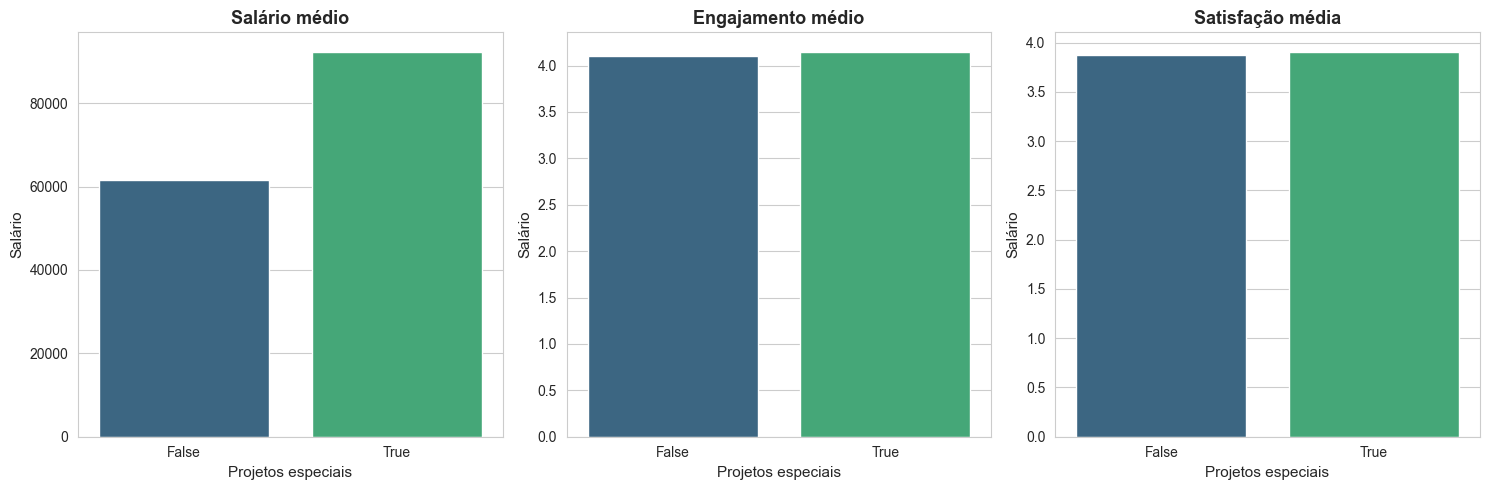

In [95]:
fig, eixos = plt.subplots(1, 3, figsize=(15,5))

projetos_salario = df.groupby(df["SpecialProjectsCount"]>0)["Salary"].mean().round(2).sort_values(ascending=False)
projetos_engajamento = df.groupby(df["SpecialProjectsCount"]>0)["EngagementSurvey"].mean().round(2).sort_values(ascending=False)
projetos_satisfacao = df.groupby(df["SpecialProjectsCount"]>0)["EmpSatisfaction"].mean().round(2).sort_values(ascending=False)

sns.barplot(x=projetos_salario.index, y=projetos_salario.values, hue=projetos_salario.index, palette=paleta, legend=False, ax=eixos[0])
eixos[0].set_title("Salário médio")
eixos[0].set_xlabel("Projetos especiais")
eixos[0].set_ylabel("Salário")

sns.barplot(x=projetos_engajamento.index, y=projetos_engajamento.values, hue=projetos_engajamento.index, palette=paleta, legend=False, ax=eixos[1])
eixos[1].set_title("Engajamento médio")
eixos[1].set_xlabel("Projetos especiais")
eixos[1].set_ylabel("Salário")

sns.barplot(x=projetos_satisfacao.index, y=projetos_satisfacao.values, hue=projetos_satisfacao.index, palette=paleta, legend=False, ax=eixos[2])
eixos[2].set_title("Satisfação média")
eixos[2].set_xlabel("Projetos especiais")
eixos[2].set_ylabel("Salário")

plt.tight_layout()
plt.show()

Funcionários que participaram de projetos especiais recebem um salário significativamente maior do que funcionários que não participaram. Além disso, receberam mais notas "Fully Meets" nas avaliações de performance. Esses fatores podem indicar que funcionários com bom desempenho estão mais propícios a participaram de projetos especiais dentro da empresa.

Em relação a comparação com o engajamento médio e satisfação média, a diferença entre os grupos é muito baixa, o que pode indicar que a participação em projetos especiais é mais evidente na remuneração do que nas percepções do funcionário.

## Outras relações

### Satisfação x Salário

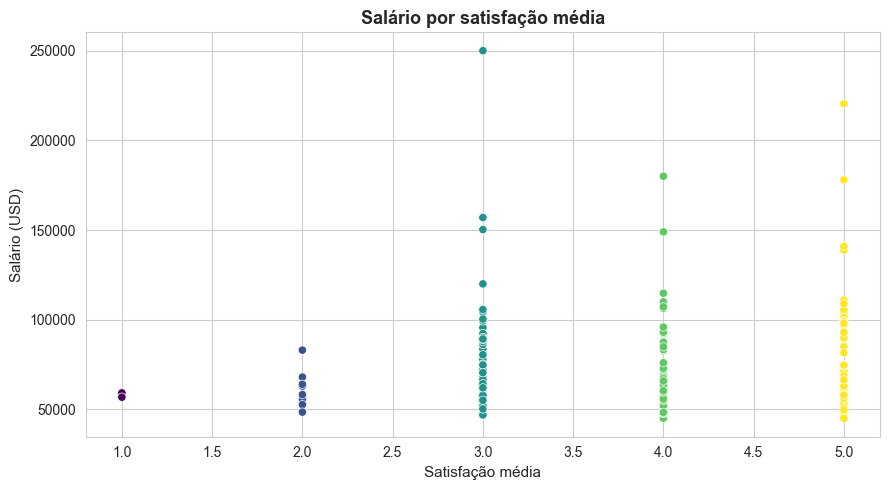

In [119]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x="EmpSatisfaction", y="Salary", hue="EmpSatisfaction", palette=paleta, legend=False)
plt.xlabel("Satisfação média")
plt.ylabel("Salário (USD)")
plt.title("Salário por satisfação média")
plt.tight_layout()
plt.show()

### Engajamento x Salário

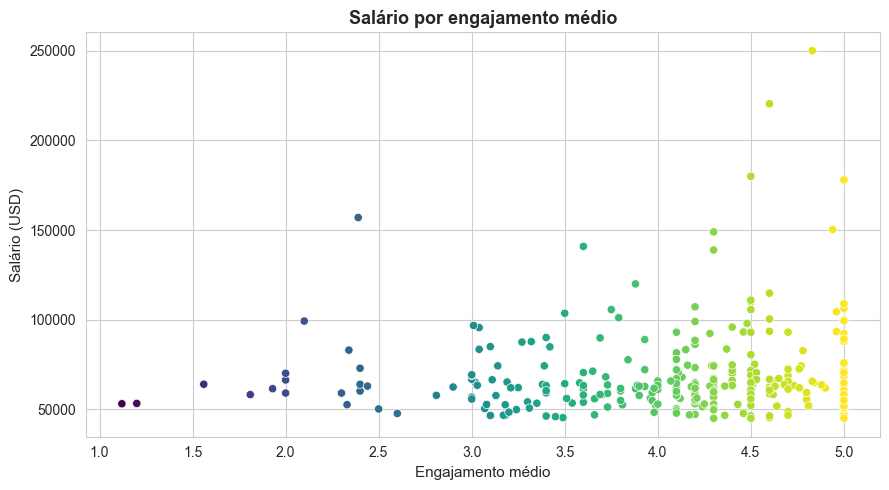

In [113]:
plt.figure(figsize=(9,5))
sns.scatterplot(data=df, x="EngagementSurvey", y="Salary", hue="EngagementSurvey", palette=paleta, legend=False)
plt.xlabel("Engajamento médio")
plt.ylabel("Salário (USD)")
plt.title("Salário por engajamento médio")
plt.tight_layout()
plt.show()

### Atrasos x Performance

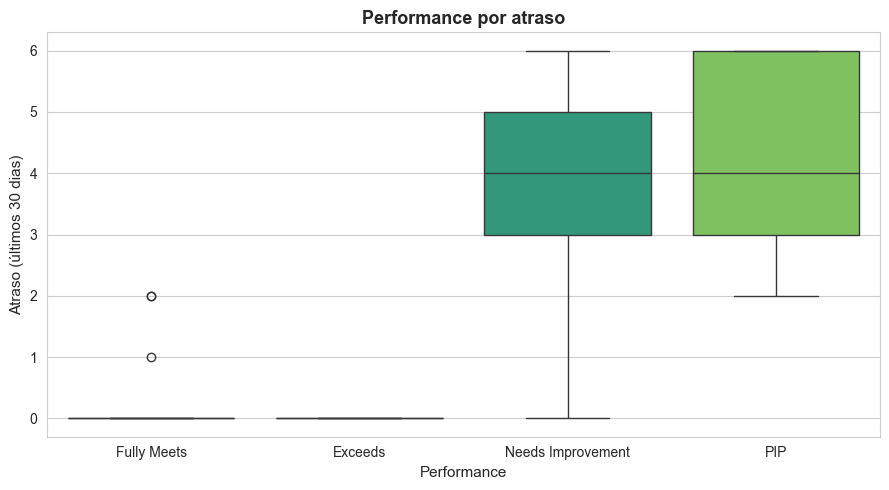

In [116]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="PerformanceScore", y="DaysLateLast30", hue="PerformanceScore", order=ordem_avaliacoes, palette=paleta, legend=False)
plt.xlabel("Performance")
plt.ylabel("Atraso (últimos 30 dias)")
plt.title("Performance por atraso")
plt.tight_layout()
plt.show()

### Faltas x Performance

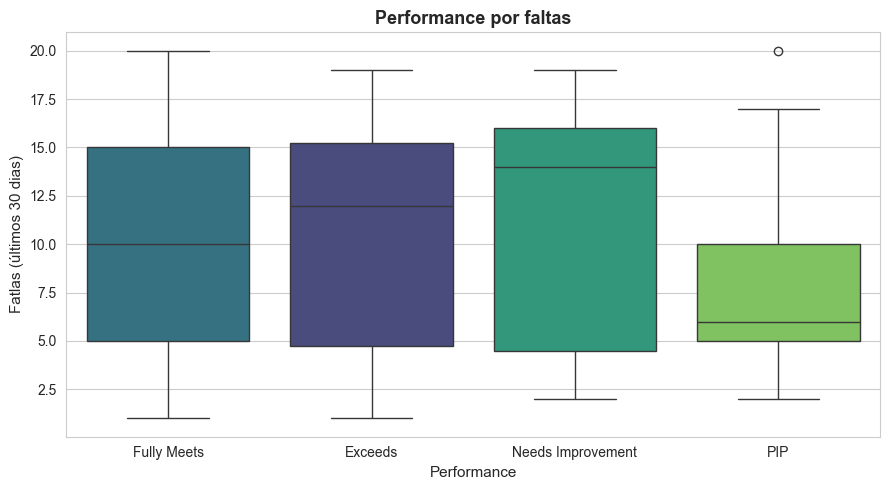

In [118]:
plt.figure(figsize=(9,5))
sns.boxplot(data=df, x="PerformanceScore", y="Absences", hue="PerformanceScore", order=ordem_avaliacoes, palette=paleta, legend=False)
plt.xlabel("Performance")
plt.ylabel("Fatlas (últimos 30 dias)")
plt.title("Performance por faltas")
plt.tight_layout()
plt.show()

Reforçando análises anteriores, o salário não varia de forma desequilibrada entre os níveis de performance, indicando que a remuneração possa estar mais atrelada a hierarquia operacional do que com um bom desempenho.

As faltas também não variam de forma desequilibrada entre os níveis de performance nesta base, indicando que não existe uma relação muito direta com a performance.

## Conclusão

A análise da base de Recursos Humanos mostrou uma empresa com 310 funcionários, turnover geral de aproximadamente 33% e salário médio próximo de 69 mil dólares. "Production" e "Software Engineering" concentram a maior rotatividade, enquanto Executive Office se destaca pela estabilidade e pelos maiores salários.

Os indicadores de satisfação e engajamento são relativamente homogêneos entre departamentos, sem um setor crítico evidente. A participação em projetos especiais aparece como o fator mais associado a salários mais altos e melhores avaliações de desempenho, o que pode indicar tanto seleção de bons profissionais para esses projetos quanto um ganho de performance gerado por eles.